In [1]:
import pandas as pd

df = pd.read_csv('data/cs-training.csv', index_col=0)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
df.shape

(150000, 11)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [4]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [5]:
df['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [6]:
df[['age', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines', 'MonthlyIncome']].describe()

,age,DebtRatio,RevolvingUtilizationOfUnsecuredLines,MonthlyIncome
count,150000.000000,150000.000000,150000.000000,1.202690e+05
mean,52.295207,353.005076,6.048438,6.670221e+03
std,14.771866,2037.818523,249.755371,1.438467e+04
min,0.000000,0.000000,0.000000,0.000000e+00
25%,41.000000,0.175074,0.029867,3.400000e+03
50%,52.000000,0.366508,0.154181,5.400000e+03
75%,63.000000,0.868254,0.559046,8.249000e+03
max,109.000000,329664.000000,50708.000000,3.008750e+06


In [7]:
# How many weird rows are there?
print("Age = 0:", (df['age'] == 0).sum())
print("DebtRatio > 10:", (df['DebtRatio'] > 10).sum())
print("Utilization > 2:", (df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum())
print("MonthlyIncome > 100000:", (df['MonthlyIncome'] > 100000).sum())

Age = 0: 1
DebtRatio > 10: 28877
Utilization > 2: 371
MonthlyIncome > 100000: 70


In [8]:
df['DebtRatio'].quantile([0.9, 0.95, 0.99, 0.999])

0.900     1267.000
0.950     2449.000
0.990     4979.040
0.999    10613.074
Name: DebtRatio, dtype: float64

In [9]:
# 1. Remove rows where age is 0
df = df[df['age'] > 0]

# 2.  Clip DebtRatio and RevolvingUtilizationOfUnsecuredLines to a maximum of 2
df['DebtRatio'] = df['DebtRatio'].clip(upper=2)
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

# 3. Fill missing values for MonthlyIncome and NumberOfDependents with median
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

# Check for missing values and shape of the cleaned DataFrame
print(df.isnull().sum())
print(df.shape)

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64
(149999, 11)


In [10]:
print(df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index(ascending=False).head(10))

NumberOfTime30-59DaysPastDueNotWorse
98    264
96      5
13      1
12      2
11      1
10      4
9      12
8      25
7      54
6     140
Name: count, dtype: int64


In [11]:
# Remove rows where NumberOfTime30-59DaysPastDueNotWorse is greater than or equal to 90
df = df[df['NumberOfTime30-59DaysPastDueNotWorse'] < 90]

print(df.shape)
print(df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index(ascending=False).head(5))

(149730, 11)
NumberOfTime30-59DaysPastDueNotWorse
13     1
12     2
11     1
10     4
9     12
Name: count, dtype: int64


In [12]:
# Feature engineering
df['TotalPastDue'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] + 
                       df['NumberOfTime60-89DaysPastDueNotWorse'] + 
                       df['NumberOfTimes90DaysLate'])

df['HasDependents'] = (df['NumberOfDependents'] > 0).astype(int)

df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalPastDue,HasDependents,IncomePerDependent
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2,1,3040.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,1,1300.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2,0,3042.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0,3300.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1,0,63588.0


In [13]:
from sklearn.model_selection import train_test_split

# Split the data into features and target variable
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Split the data into training and testing sets, stratifying by the target variable to maintain the same default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train shape: (119784, 13)
Test shape: (29946, 13)
Train default rate: 0.06597709209911173
Test default rate: 0.06598544045949375


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the features using StandardScaler so that all features have mean=0 and std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a logistic regression model with balanced class weights to handle class imbalance
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Model trained!")

Model trained!


In [15]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Make predictions on the test set
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of default

# Evaluation
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

ROC-AUC Score: 0.8481089755652022

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.81      0.89     27970
           1       0.22      0.72      0.33      1976

    accuracy                           0.81     29946
   macro avg       0.60      0.77      0.61     29946
weighted avg       0.93      0.81      0.85     29946


Confusion Matrix:
 [[22776  5194]
 [  552  1424]]


In [16]:
from xgboost import XGBClassifier

# Train XGBoost model with scale_pos_weight to handle class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)  # note: raw X_train, scaled wala nahi

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost ROC-AUC Score: 0.8392866525586263

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.84      0.90     27970
           1       0.23      0.67      0.34      1976

    accuracy                           0.83     29946
   macro avg       0.60      0.76      0.62     29946
weighted avg       0.92      0.83      0.86     29946



In [17]:
xgb_model_tuned = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)

xgb_model_tuned.fit(X_train, y_train)

y_pred_tuned = xgb_model_tuned.predict(X_test)
y_pred_proba_tuned = xgb_model_tuned.predict_proba(X_test)[:, 1]

print("Tuned XGBoost ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

Tuned XGBoost ROC-AUC Score: 0.8594131273530488

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.81      0.88     27970
           1       0.21      0.75      0.33      1976

    accuracy                           0.80     29946
   macro avg       0.60      0.78      0.61     29946
weighted avg       0.93      0.80      0.85     29946



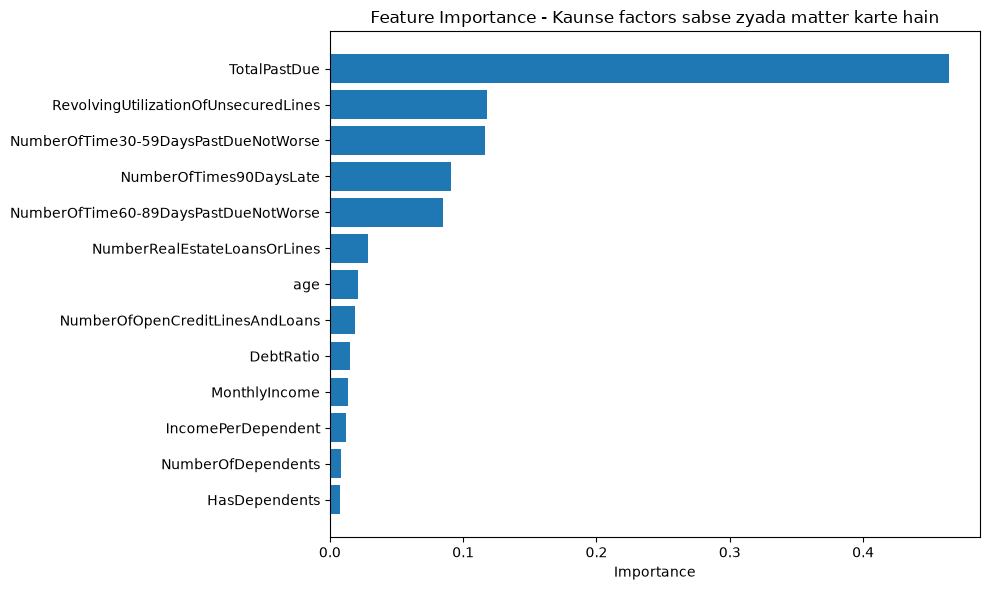

In [18]:
import matplotlib.pyplot as plt

importances = xgb_model_tuned.feature_importances_
feature_names = X_train.columns

# Sort the feature importances in descending order and plot them
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices][::-1])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices][::-1])
plt.xlabel("Importance")
plt.title("Feature Importance - Kaunse factors sabse zyada matter karte hain")
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

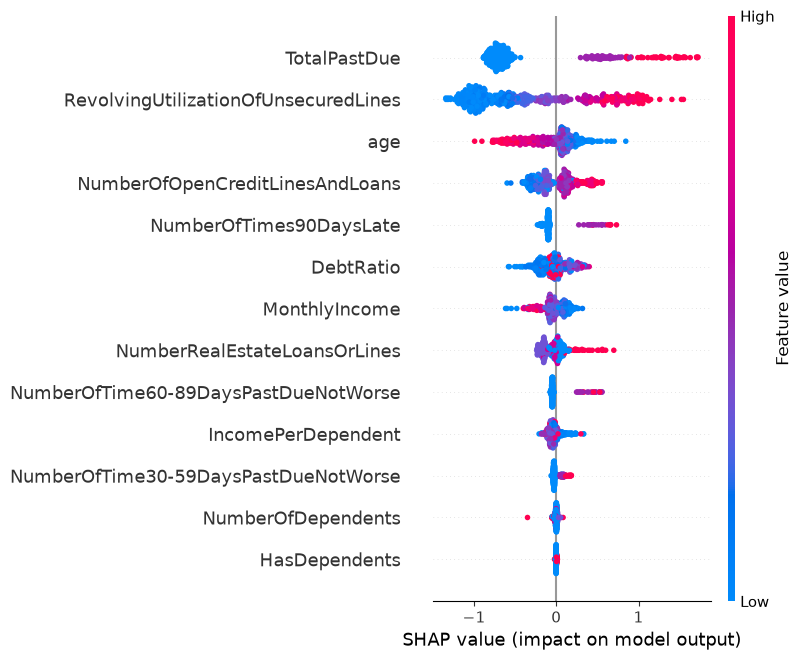

In [19]:
import shap

explainer = shap.TreeExplainer(xgb_model_tuned)

X_sample = X_test.sample(500, random_state=42)

# Compute SHAP values for the sample
shap_values = explainer(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample, feature_names=X_train.columns)

In [20]:
import numpy as np

# Business costs (illustrative estimates)
COST_FALSE_NEGATIVE = 5000   # missed defaulter - lost loan amount
COST_FALSE_POSITIVE = 500    # wrongly rejected safe applicant - lost profit

# Try different thresholds and calculate total cost at each
thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_pred_proba_tuned >= t).astype(int)
    
    fn = ((y_test == 1) & (y_pred_t == 0)).sum()
    fp = ((y_test == 0) & (y_pred_t == 1)).sum()
    
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    results.append({'threshold': t, 'false_negatives': fn, 'false_positives': fp, 'total_cost': total_cost})

cost_df = pd.DataFrame(results)
cost_df

,threshold,false_negatives,false_positives,total_cost
0,0.05,7,26089,13079500
1,0.10,36,20840,10600000
2,0.15,87,16798,8834000
3,0.20,123,14063,7646500
4,0.25,179,12011,6900500
5,0.30,242,10295,6357500
6,0.35,300,8825,5912500
7,0.40,352,7588,5554000
8,0.45,415,6460,5305000
9,0.50,485,5449,5149500


Optimal threshold: 0.55
Total cost at optimal threshold: $5,115,500
Total cost at default (0.50) threshold: $5,149,500


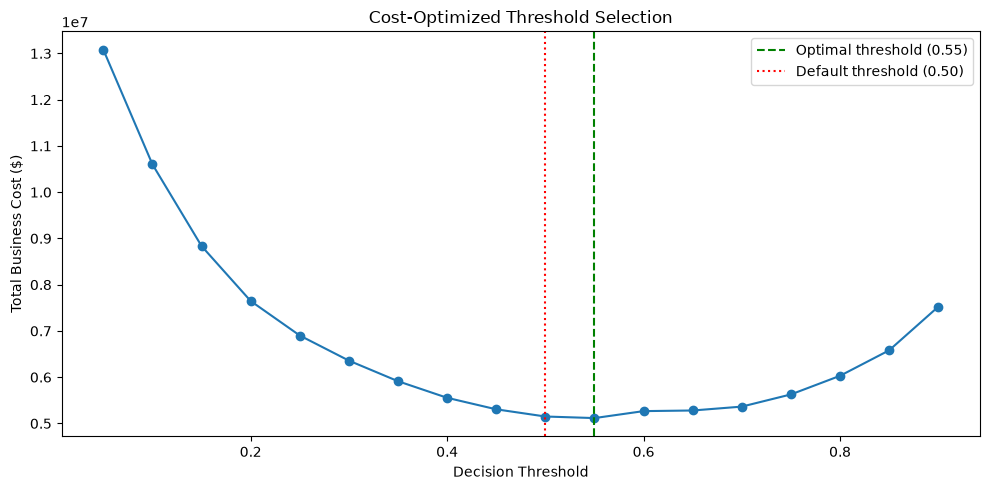

In [21]:
optimal_row = cost_df.loc[cost_df['total_cost'].idxmin()]
print(f"Optimal threshold: {optimal_row['threshold']:.2f}")
print(f"Total cost at optimal threshold: ${optimal_row['total_cost']:,.0f}")
print(f"Total cost at default (0.50) threshold: ${cost_df[cost_df['threshold']==0.50]['total_cost'].values[0]:,.0f}")

plt.figure(figsize=(10, 5))
plt.plot(cost_df['threshold'], cost_df['total_cost'], marker='o')
plt.axvline(x=optimal_row['threshold'], color='green', linestyle='--', label=f"Optimal threshold ({optimal_row['threshold']:.2f})")
plt.axvline(x=0.5, color='red', linestyle=':', label='Default threshold (0.50)')
plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost ($)")
plt.title("Cost-Optimized Threshold Selection")
plt.legend()
plt.tight_layout()
plt.savefig('threshold_optimization.png')
plt.show()